<a href="https://colab.research.google.com/github/anu46464/smart---building--occupancy--detection/blob/main/final_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 # **Smart Building IoT: Detecting Room Occupancy Using Environmental Sensors.**




# **Data Loading and Initial Inspection**

In [2]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('datatraining.txt')
test_df1 = pd.read_csv('datatest.txt')
test_df2 = pd.read_csv('datatest2.txt')

# Combine test sets for broader evaluation if desired
test_df = pd.concat([test_df1, test_df2])

print("Training data shape:", train_df.shape)
print(train_df.head())

Training data shape: (8143, 7)
                  date  Temperature  Humidity  Light     CO2  HumidityRatio  \
1  2015-02-04 17:51:00        23.18   27.2720  426.0  721.25       0.004793   
2  2015-02-04 17:51:59        23.15   27.2675  429.5  714.00       0.004783   
3  2015-02-04 17:53:00        23.15   27.2450  426.0  713.50       0.004779   
4  2015-02-04 17:54:00        23.15   27.2000  426.0  708.25       0.004772   
5  2015-02-04 17:55:00        23.10   27.2000  426.0  704.50       0.004757   

   Occupancy  
1          1  
2          1  
3          1  
4          1  
5          1  


# **Data Cleaning**

In [3]:
def clean_data(df):
    # Remove index column if it exists (often first column in these txt files)
    if 'Unnamed: 0' in df.columns or df.iloc[:, 0].dtype == 'int64':
         # In your files, the first column appears as a string index "1", "2" etc.
         df = df.drop(df.columns[0], axis=1)

    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Check for missing values
    if df.isnull().sum().sum() > 0:
        df = df.dropna()

    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

# **Exploratory Data Analysis (EDA)**

## **Target distribution graph and Correlation HeatMap**

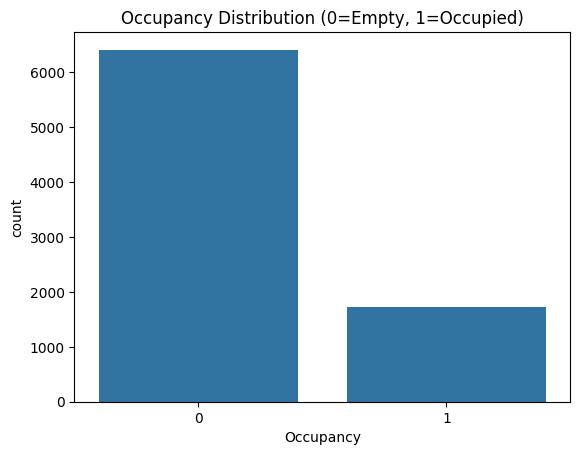

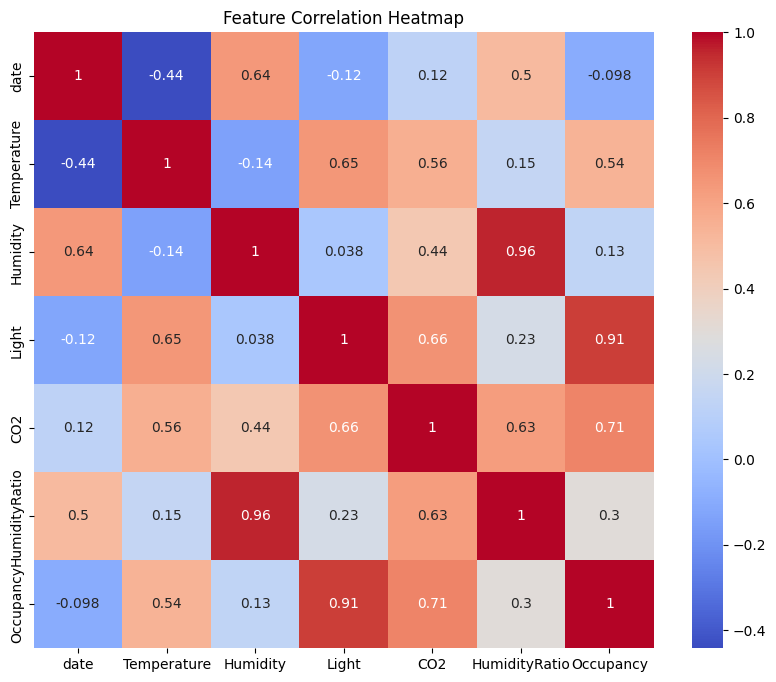

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Check Class Balance
sns.countplot(x='Occupancy', data=train_df)
plt.title('Occupancy Distribution (0=Empty, 1=Occupied)')
plt.show()

# 2. Correlation Analysis
# Light and CO2 are often the strongest predictors of human presence.
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## **Box Plot**

/tmp/ipykernel_986/184356101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train_df[col], x=train_df['Occupancy'], palette='Set2')
/tmp/ipykernel_986/184356101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train_df[col], x=train_df['Occupancy'], palette='Set2')
/tmp/ipykernel_986/184356101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train_df[col], x=train_df['Occupancy'], palette='Set2')
/tmp/ipykernel_986/184356101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

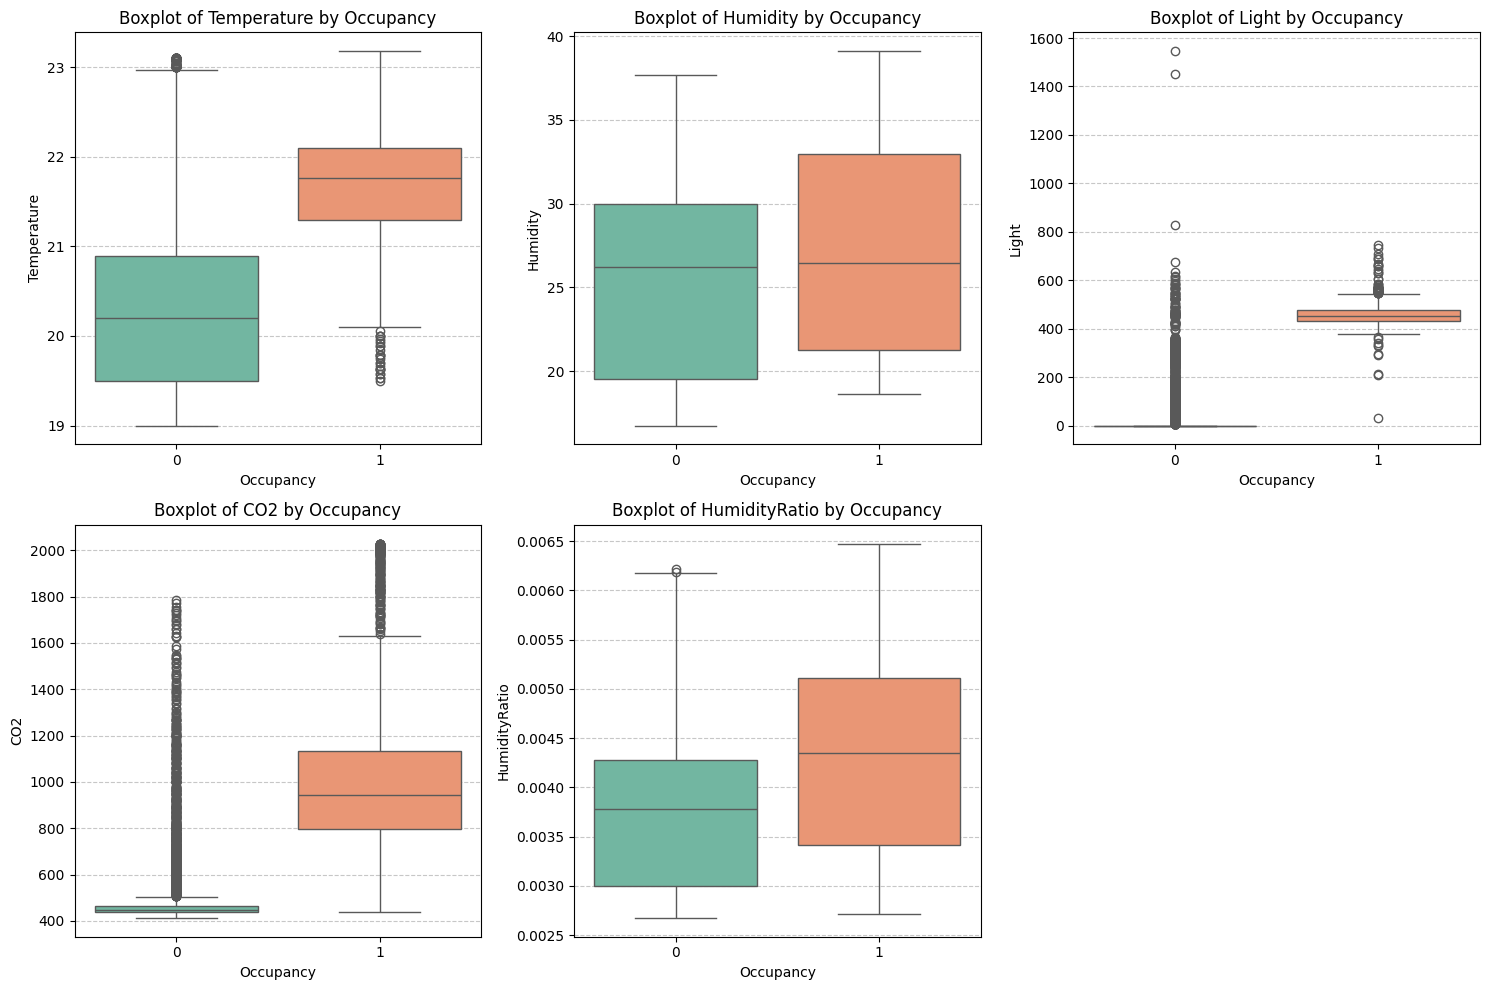

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical features to plot
features = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']

# Create a multi-figure box plot
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=train_df[col], x=train_df['Occupancy'], palette='Set2')
    plt.title(f'Boxplot of {col} by Occupancy')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **Scatter Plot**

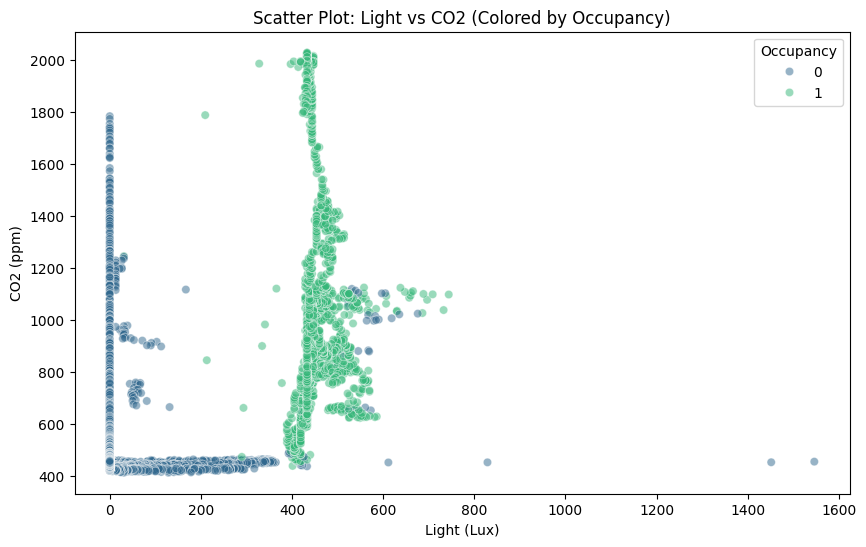

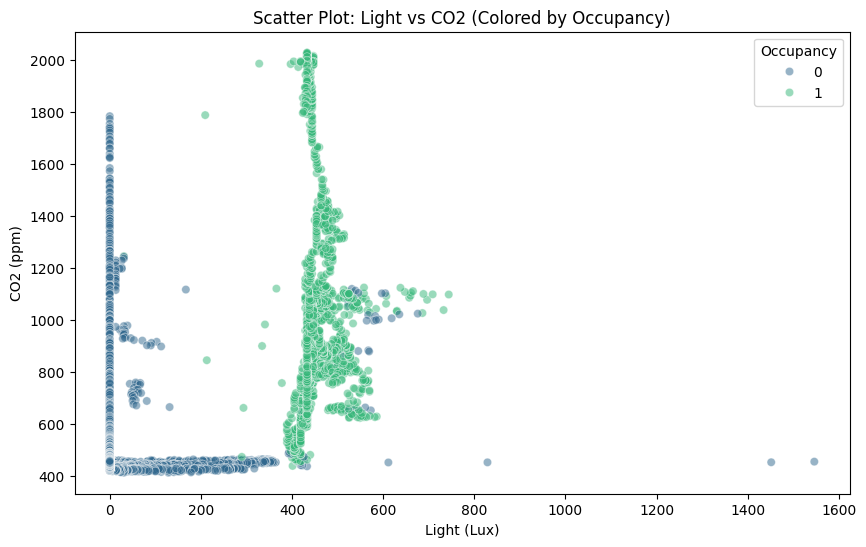

In [6]:
# Scatter plot: Light vs CO2 colored by Occupancy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Light', y='CO2', hue='Occupancy', alpha=0.5, palette='viridis')
plt.title('Scatter Plot: Light vs CO2 (Colored by Occupancy)')
plt.xlabel('Light (Lux)')
plt.ylabel('CO2 (ppm)')
plt.legend(title='Occupancy', loc='upper right')
plt.show()# Scatter plot: Light vs CO2 colored by Occupancy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_df, x='Light', y='CO2', hue='Occupancy', alpha=0.5, palette='viridis')
plt.title('Scatter Plot: Light vs CO2 (Colored by Occupancy)')
plt.xlabel('Light (Lux)')
plt.ylabel('CO2 (ppm)')
plt.legend(title='Occupancy', loc='upper right')
plt.show()

## **Pair Plot**

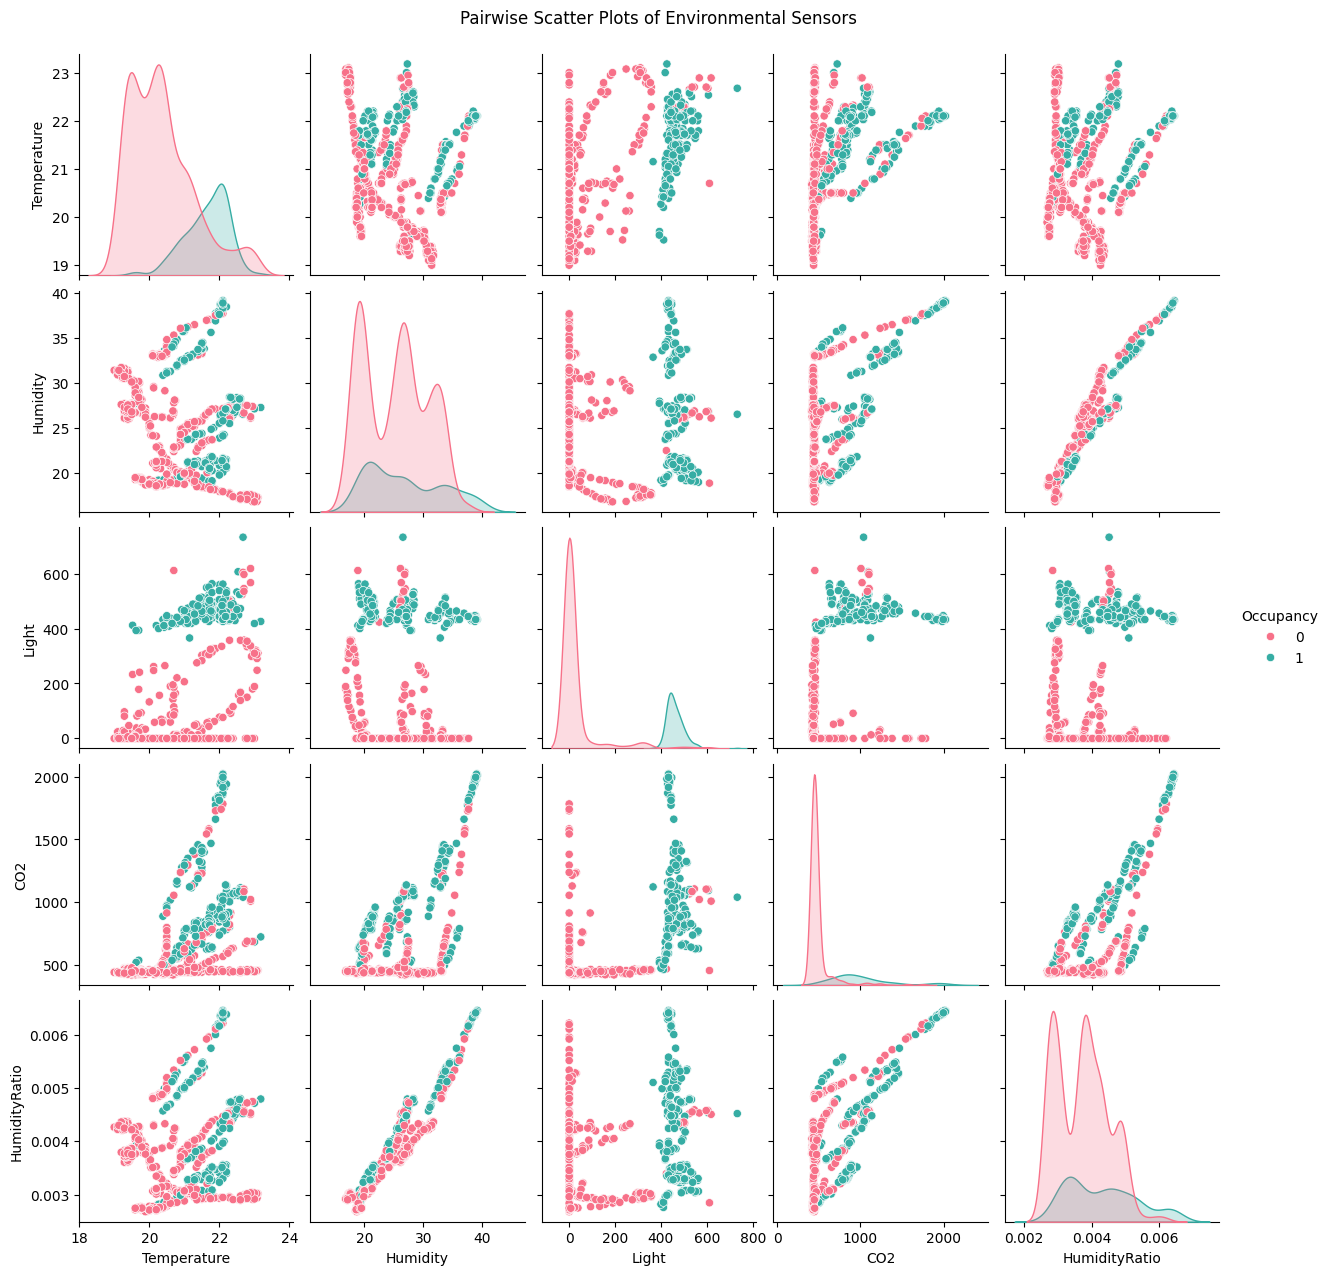

In [7]:
# We use a sample of 1000 points to keep the visualization clear
sns.pairplot(train_df.sample(1000)[features + ['Occupancy']], hue='Occupancy', diag_kind='kde', palette='husl')
plt.suptitle('Pairwise Scatter Plots of Environmental Sensors', y=1.02)
plt.show()

# **Feature Engineering**

In [8]:
def add_time_features(df):
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    # Is it a weekend? Occupancy drops significantly then.
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    return df

train_df = add_time_features(train_df)

In [9]:
train_df.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,hour,day_of_week,is_weekend
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1,17,2,0
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1,17,2,0
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1,17,2,0
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1,17,2,0
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1,17,2,0


# **Data Preprocessing for Model training**

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Convert date to numeric components
# (Since your head shows hour and day_of_week already exist, we ensure they are numeric)
# If your 'date' column is a string, convert it first:
train_df['date'] = pd.to_datetime(train_df['date'])

# 2. Selecting Features and Target
# We drop 'date' because models can't handle raw timestamps
X = train_df.drop(['Occupancy', 'date'], axis=1)
y = train_df['Occupancy']

# 3. Standardization
# We fit the scaler ONLY on the training data later to avoid data leakage,
# but here is the setup for the numerical columns.
num_cols = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
scaler = StandardScaler()

# 4. Train-Test Split (80% Train, 20% Test)
# We use stratify=y to ensure both sets have the same percentage of occupied/vacant labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 5. Apply Scaling
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (6514, 8)
Testing set shape: (1629, 8)



# **Model Training**
## **Defining and Training Models**

In [11]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Dictionary to store trained models and their training times
trained_models = {}
train_times = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    trained_models[name] = model
    train_times[name] = end_time - start_time
    print(f"Finished training {name} in {train_times[name]:.4f} seconds.")

Finished training Logistic Regression in 0.0308 seconds.
Finished training Gradient Boosting in 0.8590 seconds.
Finished training KNN in 0.0086 seconds.


## **Evaluating Model**

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Train Time (s)": train_times[name]
    })

# Display as a clean DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.984653   0.942149  0.988439  0.964739   
1    Gradient Boosting  0.993861   0.977273  0.994220  0.985673   
2                  KNN  0.993861   0.977273  0.994220  0.985673   

   Train Time (s)  
0        0.030838  
1        0.858977  
2        0.008595  


## **Visualization**

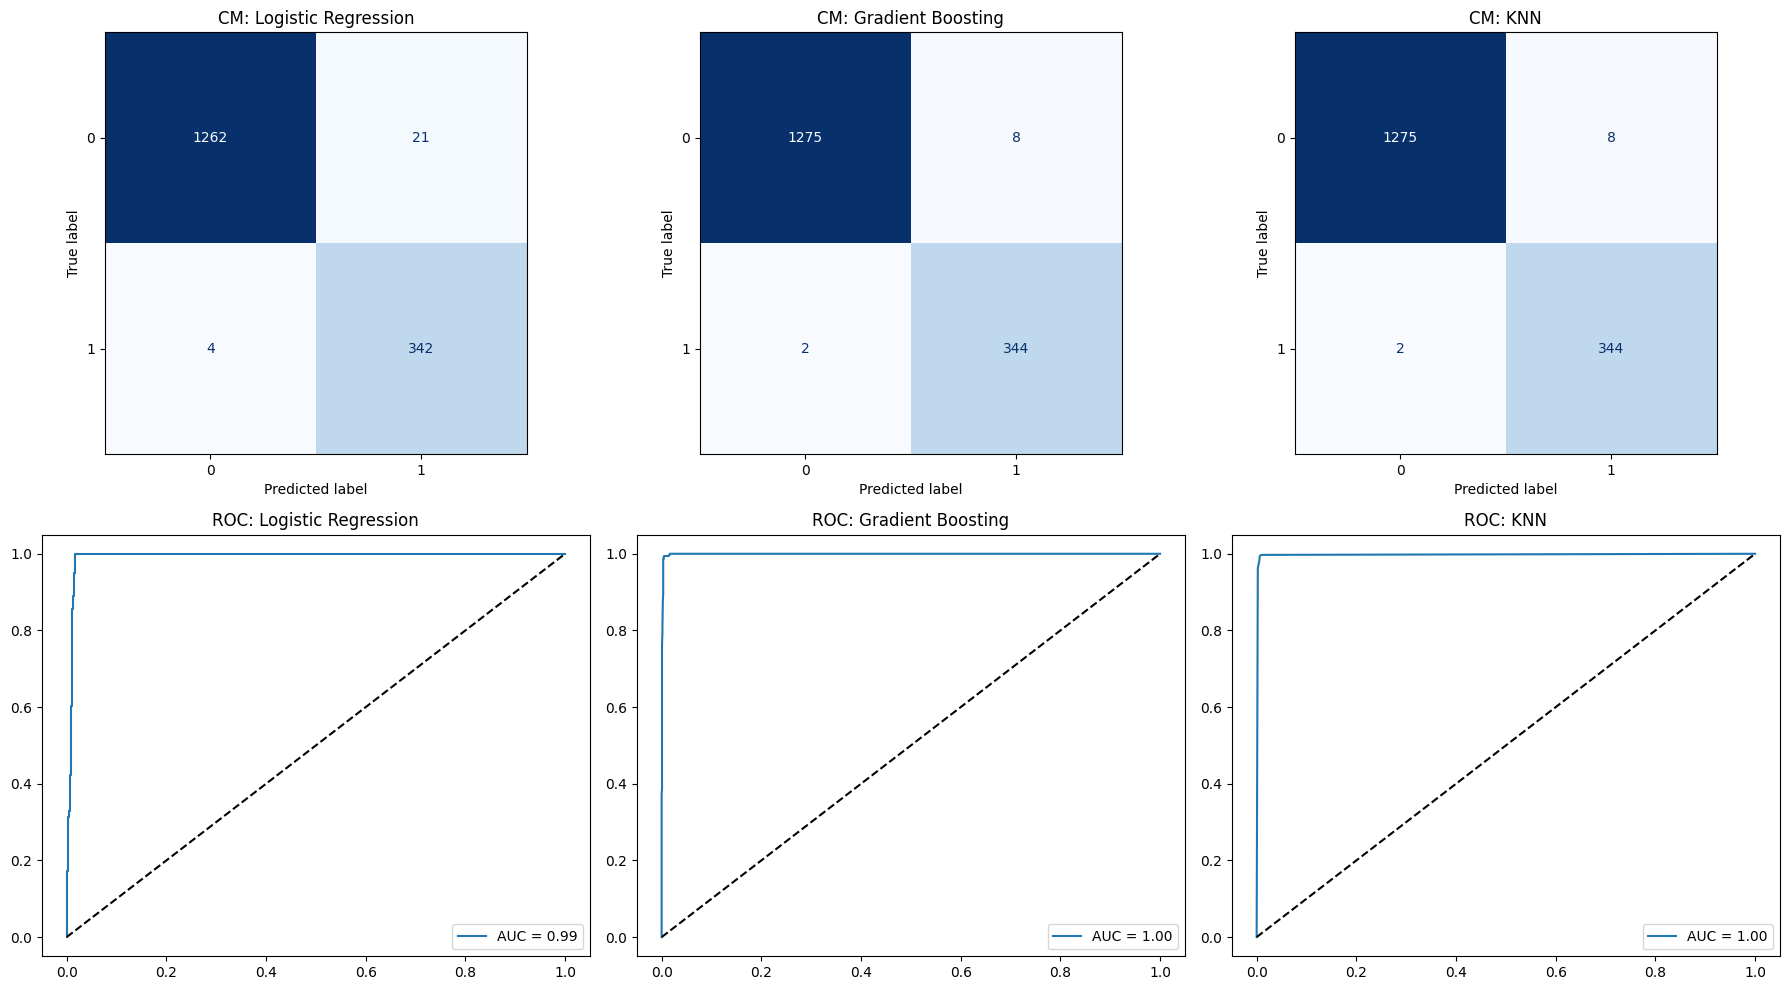

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (name, model) in enumerate(trained_models.items()):
    # 1. Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0, i], cmap='Blues', colorbar=False)
    axes[0, i].set_title(f"CM: {name}")

    # 2. ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else: # For models without predict_proba
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1, i].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    axes[1, i].plot([0, 1], [0, 1], 'k--')
    axes[1, i].set_title(f"ROC: {name}")
    axes[1, i].legend(loc='lower right')

plt.tight_layout()
plt.show()

## **Hyperparameter Optimization using Grid Search**

Optimizing Logistic Regression...
Optimizing Gradient Boosting...
Optimizing KNN...

============================== FINAL EVALUATION ==============================

Model: Logistic Regression
Best Parameters: {'C': 0.1, 'solver': 'lbfgs'}
F1 Score: 0.9705 | Accuracy: 0.9871

Model: Gradient Boosting
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 50}
F1 Score: 0.9843 | Accuracy: 0.9932

Model: KNN
Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
F1 Score: 0.9856 | Accuracy: 0.9939


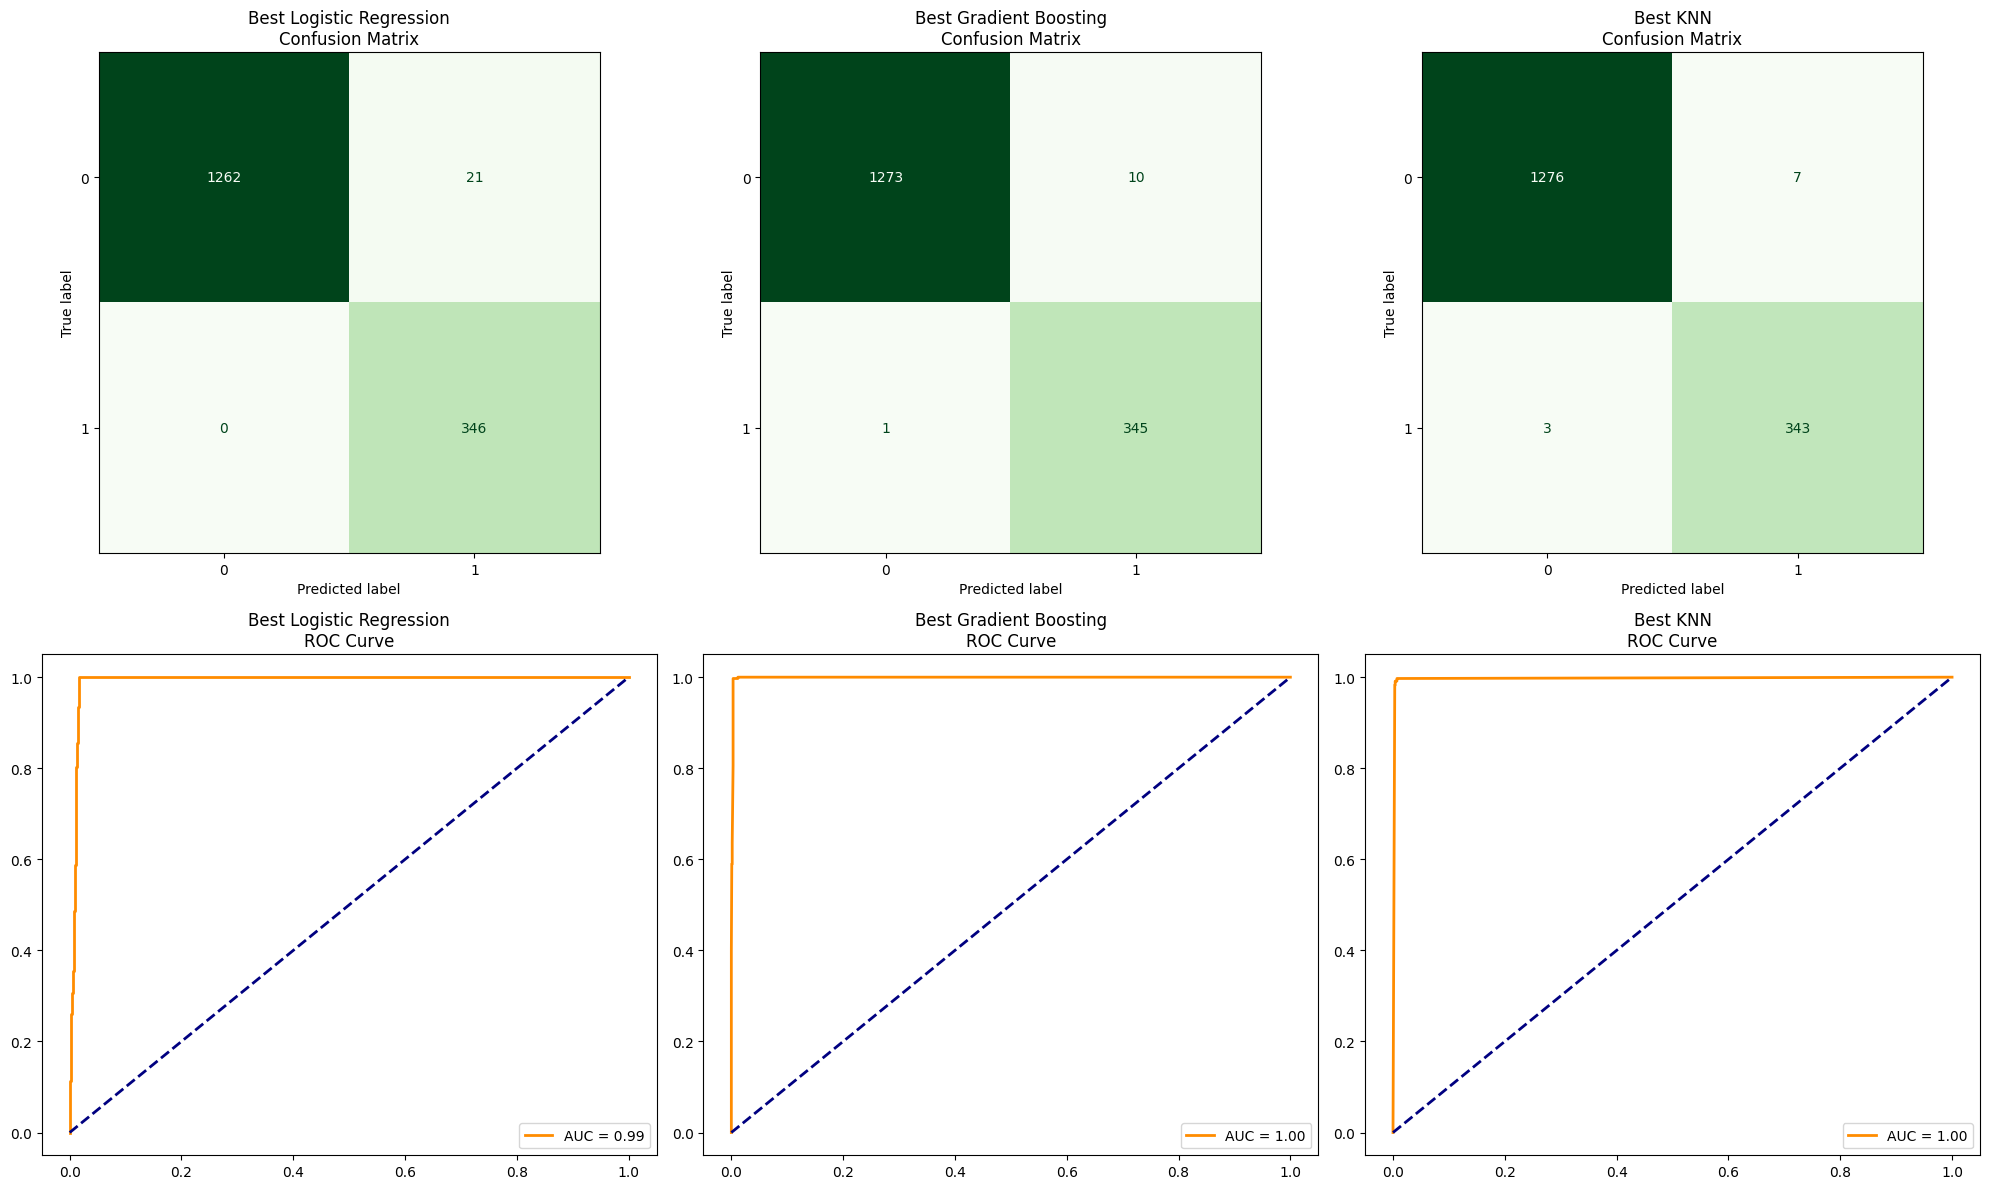

In [14]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)

# 1. Define Parameter Grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    "Gradient Boosting": {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "KNN": {
        'n_neighbors': [3, 5, 11],
        'weights': ['uniform', 'distance']
    }
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

final_results = []
best_estimators = {}

# Visualization Setup
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for i, (name, model) in enumerate(models.items()):
    print(f"Optimizing {name}...")

    # 2. Hyperparameter Optimization using Grid Search
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='f1', n_jobs=-1)

    start_train = time.time()
    grid_search.fit(X_train, y_train)
    end_train = time.time()

    # Get Best Model
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model

    # 3. Evaluation and Timing
    start_test = time.time()
    y_pred = best_model.predict(X_test)
    end_test = time.time()

    # Collect Metrics
    final_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "Train Time (s)": end_train - start_train,
        "Test Time (s)": end_test - start_test
    })

    # 4. Visualization - Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0, i], cmap='Greens', colorbar=False)
    axes[0, i].set_title(f"Best {name}\nConfusion Matrix")

    # 5. Visualization - ROC Curve
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[1, i].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1, i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1, i].set_title(f"Best {name}\nROC Curve")
    axes[1, i].legend(loc='lower right')

# Print Table and Best Parameters
results_df = pd.DataFrame(final_results)
print("\n" + "="*30 + " FINAL EVALUATION " + "="*30)
for index, row in results_df.iterrows():
    print(f"\nModel: {row['Model']}")
    print(f"Best Parameters: {row['Best Params']}")
    print(f"F1 Score: {row['F1 Score']:.4f} | Accuracy: {row['Accuracy']:.4f}")

plt.tight_layout()
plt.show()

## **K-Fold Cross Validation**

In [15]:
from sklearn.model_selection import cross_validate, KFold
import pandas as pd
import numpy as np

# 1. K-Fold configuration (5 Folds represent a robust standard)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Defining metrics to calculate
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1']

cv_results_list = []

print("Starting K-Fold Cross Validation...\n")

for name, model in best_estimators.items():
    # 3. Performing Cross Validation
    # We use the 'best_estimators' from the previous grid search for optimal results
    cv_scores = cross_validate(model, X, y, cv=kf, scoring=scoring_metrics)

    # 4. Compiling Mean and Standard Deviation for each metric
    cv_results_list.append({
        "Model": name,
        "Accuracy (Mean)": np.mean(cv_scores['test_accuracy']),
        "Accuracy (Std)": np.std(cv_scores['test_accuracy']),
        "Precision (Mean)": np.mean(cv_scores['test_precision']),
        "Precision (Std)": np.std(cv_scores['test_precision']),
        "Recall (Mean)": np.mean(cv_scores['test_recall']),
        "Recall (Std)": np.std(cv_scores['test_recall']),
        "F1 (Mean)": np.mean(cv_scores['test_f1']),
        "F1 (Std)": np.std(cv_scores['test_f1'])
    })

# 5. Displaying the final results in a clean table
cv_final_df = pd.DataFrame(cv_results_list)

# Formatting for better readability
pd.options.display.float_format = '{:,.4f}'.format
print("="*40 + " K-FOLD CROSS VALIDATION RESULTS " + "="*40)
print(cv_final_df.to_string(index=False))

# Quick Insight for Research Questions
print("\nInsight:")
print("- Low Standard Deviation (Std) suggests the model is consistent across different data subsets.")
print("- High F1-Mean indicates the model is handling the Occupancy detection reliably.")

Starting K-Fold Cross Validation...

======================================== K-FOLD CROSS VALIDATION RESULTS ========================================
              Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)  F1 (Mean)  F1 (Std)
Logistic Regression           0.9875          0.0015            0.9498           0.0113         0.9932        0.0049     0.9709    0.0048
  Gradient Boosting           0.9934          0.0022            0.9811           0.0061         0.9880        0.0058     0.9845    0.0046
                KNN           0.9897          0.0022            0.9689           0.0056         0.9827        0.0081     0.9758    0.0054

Insight:
- Low Standard Deviation (Std) suggests the model is consistent across different data subsets.
- High F1-Mean indicates the model is handling the Occupancy detection reliably.


# **Impact of Sensor Dominance and Failure Analysis**

/tmp/ipykernel_986/203399032.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax[0], palette='viridis')
/tmp/ipykernel_986/203399032.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='F1 Score', data=comparison_df, ax=ax[1], palette='magma')


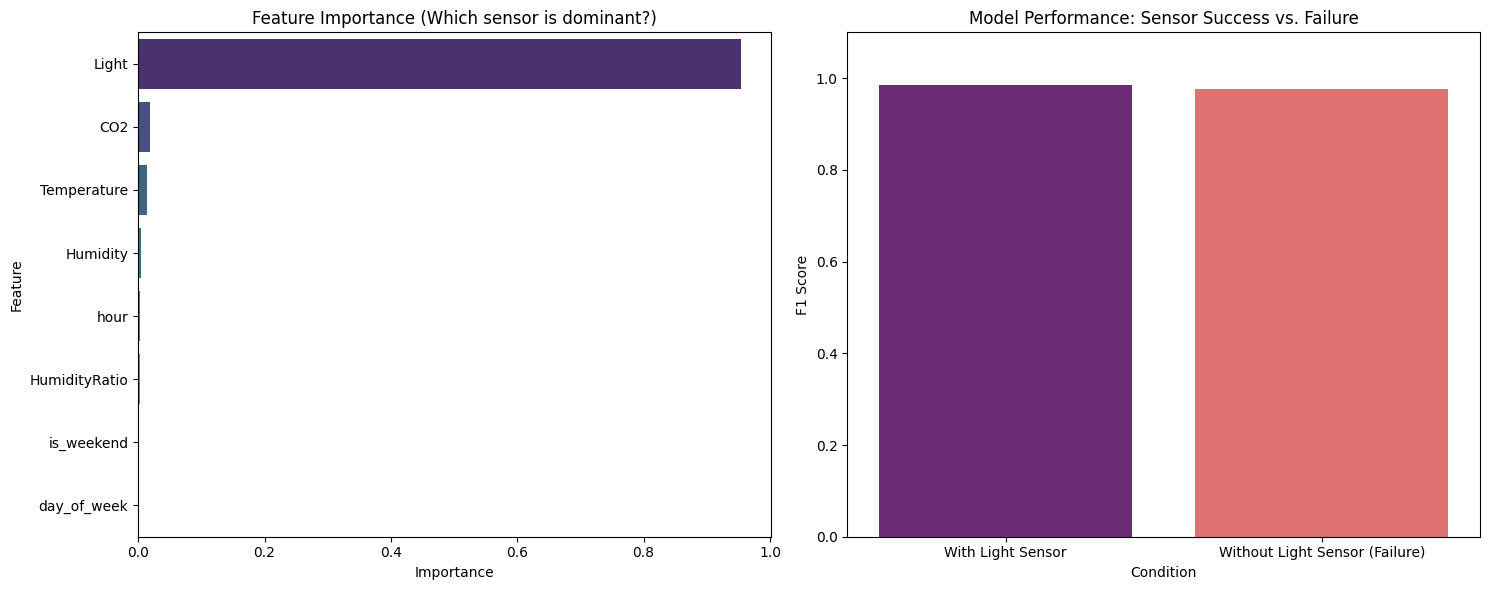

F1 Score with Light sensor: 0.9843
F1 Score without Light sensor: 0.9757
Performance Drop: 0.88%


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score

# 1. Feature Importance Analysis
# We use the optimized Gradient Boosting model to identify the dominant predictor
best_gb = best_estimators["Gradient Boosting"]
importances = best_gb.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# 2. Simulating Sensor Failure (Dropping 'Light')
X_train_no_light = X_train.drop(columns=['Light'])
X_test_no_light = X_test.drop(columns=['Light'])

# Re-train model on the "failed" dataset
gb_no_light = GradientBoostingClassifier(**best_gb.get_params())
gb_no_light.fit(X_train_no_light, y_train)

# 3. Comparing Performance
y_pred_with = best_gb.predict(X_test)
y_pred_without = gb_no_light.predict(X_test_no_light)

f1_with = f1_score(y_test, y_pred_with)
f1_without = f1_score(y_test, y_pred_without)

# 4. Visualizing Results
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: Feature Importance
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=ax[0], palette='viridis')
ax[0].set_title('Feature Importance (Which sensor is dominant?)')

# Plot B: Performance Comparison
comparison_df = pd.DataFrame({
    'Condition': ['With Light Sensor', 'Without Light Sensor (Failure)'],
    'F1 Score': [f1_with, f1_without]
})
sns.barplot(x='Condition', y='F1 Score', data=comparison_df, ax=ax[1], palette='magma')
ax[1].set_ylim(0, 1.1)
ax[1].set_title('Model Performance: Sensor Success vs. Failure')

plt.tight_layout()
plt.show()

print(f"F1 Score with Light sensor: {f1_with:.4f}")
print(f"F1 Score without Light sensor: {f1_without:.4f}")
print(f"Performance Drop: {((f1_with - f1_without) / f1_with) * 100:.2f}%")

# **Temporal Generalization Analysis**

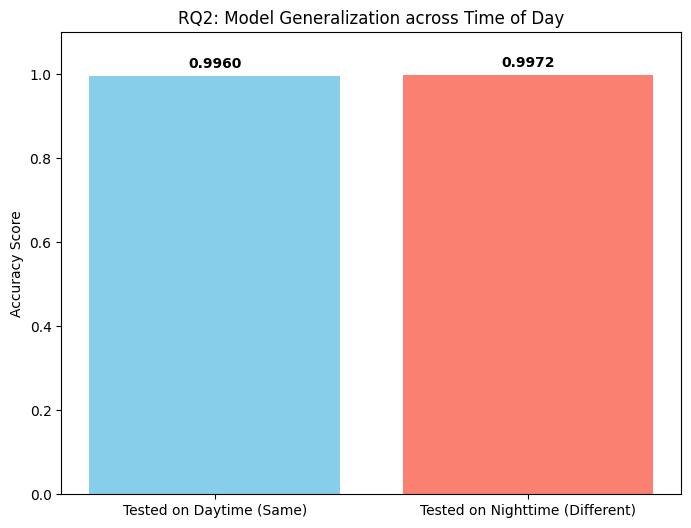

Accuracy on Training Time (Day): 0.9960
Accuracy on Different Time (Night): 0.9972
F1 Score on Nighttime: 0.8219


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 1. Define 'Day' and 'Night' thresholds
# Assuming business hours are 08:00 to 18:00
day_start = 8
day_end = 18

# 2. Split the original data into Day and Night subsets
day_data = train_df[(train_df['hour'] >= day_start) & (train_df['hour'] <= day_end)]
night_data = train_df[(train_df['hour'] < day_start) | (train_df['hour'] > day_end)]

# 3. Prepare Features and Target for both sets
X_day = day_data.drop(['Occupancy', 'date'], axis=1)
y_day = day_data['Occupancy']

X_night = night_data.drop(['Occupancy', 'date'], axis=1)
y_night = night_data['Occupancy']

# 4. Train model on Daytime data ONLY
# Using Gradient Boosting as the representative model
model_time_test = GradientBoostingClassifier(**best_estimators["Gradient Boosting"].get_params())
model_time_test.fit(X_day, y_day)

# 5. Test on both Day (In-distribution) and Night (Out-of-distribution)
y_pred_day = model_time_test.predict(X_day)
y_pred_night = model_time_test.predict(X_night)

acc_day = accuracy_score(y_day, y_pred_day)
acc_night = accuracy_score(y_night, y_pred_night)
f1_night = f1_score(y_night, y_pred_night)

# 6. Results Visualization
labels = ['Tested on Daytime (Same)', 'Tested on Nighttime (Different)']
accuracies = [acc_day, acc_night]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['skyblue', 'salmon'])
plt.ylabel('Accuracy Score')
plt.title('RQ2: Model Generalization across Time of Day')
plt.ylim(0, 1.1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

print(f"Accuracy on Training Time (Day): {acc_day:.4f}")
print(f"Accuracy on Different Time (Night): {acc_night:.4f}")
print(f"F1 Score on Nighttime: {f1_night:.4f}")

# **Explainable AI (XAI) and Non-Linearity**

<Figure size 1000x600 with 0 Axes>

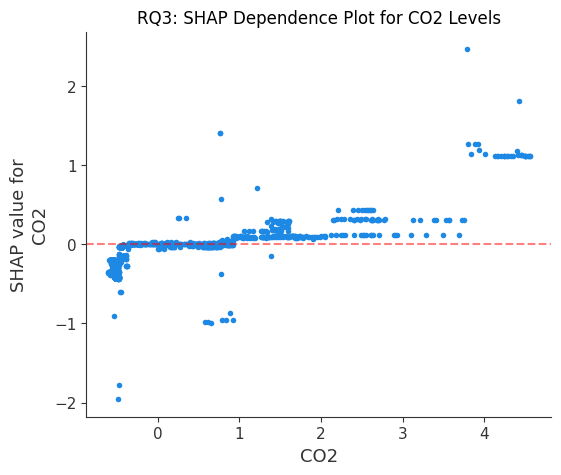

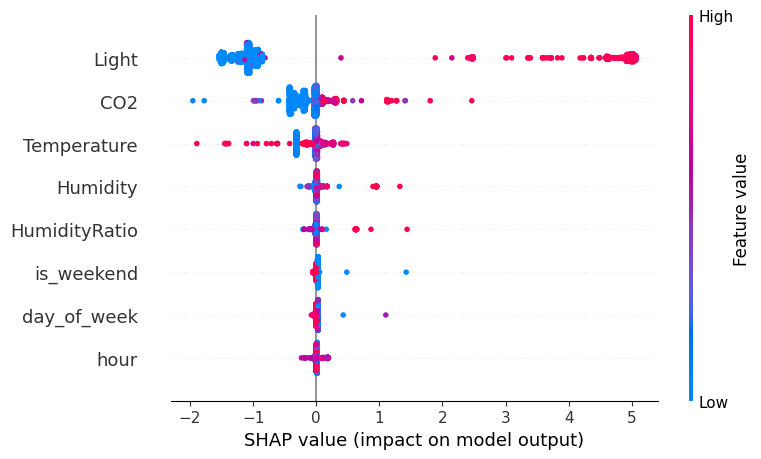

In [18]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# We use the TreeExplainer for our optimized Gradient Boosting model
explainer = shap.TreeExplainer(best_estimators["Gradient Boosting"])

# 2. Calculate SHAP values for the test set
# This might take a moment depending on the size of X_test
shap_values = explainer.shap_values(X_test)

# 3. Visualization: SHAP Dependence Plot for CO2
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    "CO2",
    shap_values,
    X_test,
    interaction_index=None,  # Set to None to focus purely on CO2
    show=False
)

plt.title("RQ3: SHAP Dependence Plot for CO2 Levels")
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Zero line represents no impact
plt.show()

# 4. Summary Plot (Optional but helpful for context)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")